In [1]:
# Importo las librerías para trabajar de acá en adelante.

# Librerías externas NumPy, SciPy y Matplotlib
from scipy.signal import TransferFunction
from scipy import signal as sig
import matplotlib.pyplot as plt
import numpy as np

# Librería de TC2
from pytc2.sistemas_lineales import pzmap, GroupDelay, bodePlot

/home/renzo/TC2_renzo/lib/python3.12/site-packages/scipy/signal/_ltisys.py:603: BadCoefficients: Badly conditioned filter coefficients (numerator): the results may be meaningless
  self.num, self.den = normalize(*system)


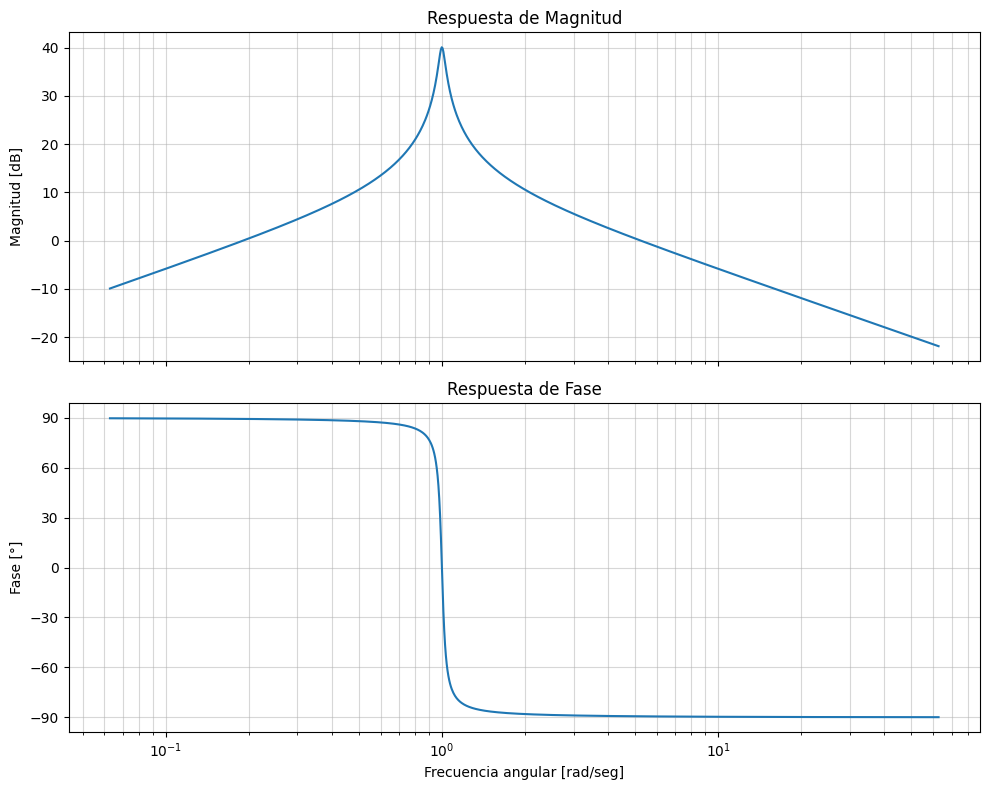

(1, <Axes: xlabel='$\\sigma$', ylabel='j$\\omega$'>)

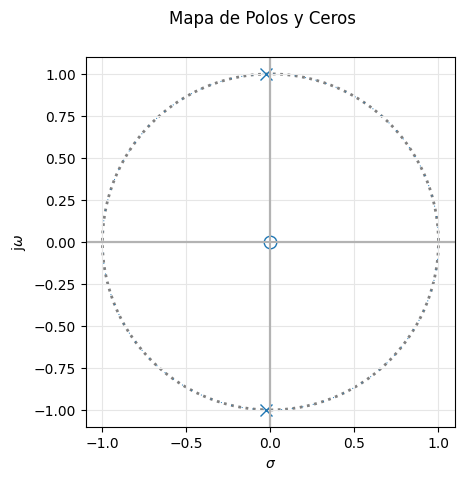

In [2]:
# Valores Normalizados
RN = 20
CN = 1
C2N = 1
R1N = 10
R3N = 10
R4N = 100
R5N = 1
LN = (C2N*R1N*R3N*R5N)/R4N


numN = np.array([0, (R4N+R5N)/(CN*R5N*RN), 0])
denN = np.array([1, 1/(RN*CN), 1/(LN*CN)])

TN = TransferFunction(numN, denN)


plt.close('all')

fN = np.logspace(-2, 1, 1000)
wN = 2*np.pi*fN

wN, magN, phaseN = sig.bode(TN,wN)

fig, (ax_magN, ax_phaseN) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

# Gráfico de Magnitud
ax_magN.semilogx(wN, magN)
ax_magN.set_title('Respuesta de Magnitud')
ax_magN.set_ylabel('Magnitud [dB]')
ax_magN.grid(True, which="both", ls="-", alpha=0.5)


# Gráfico de Fase
ticksN = np.arange(-90, 91, 30)
ax_phaseN.set_yticks(ticksN)

ax_phaseN.semilogx(wN, phaseN)
ax_phaseN.set_title('Respuesta de Fase')
ax_phaseN.set_ylabel('Fase [°]')
ax_phaseN.set_xlabel('Frecuencia angular [rad/seg]')
ax_phaseN.grid(True, which="both", ls="-", alpha=0.5)

plt.tight_layout()
plt.show()

pzmap(TN)



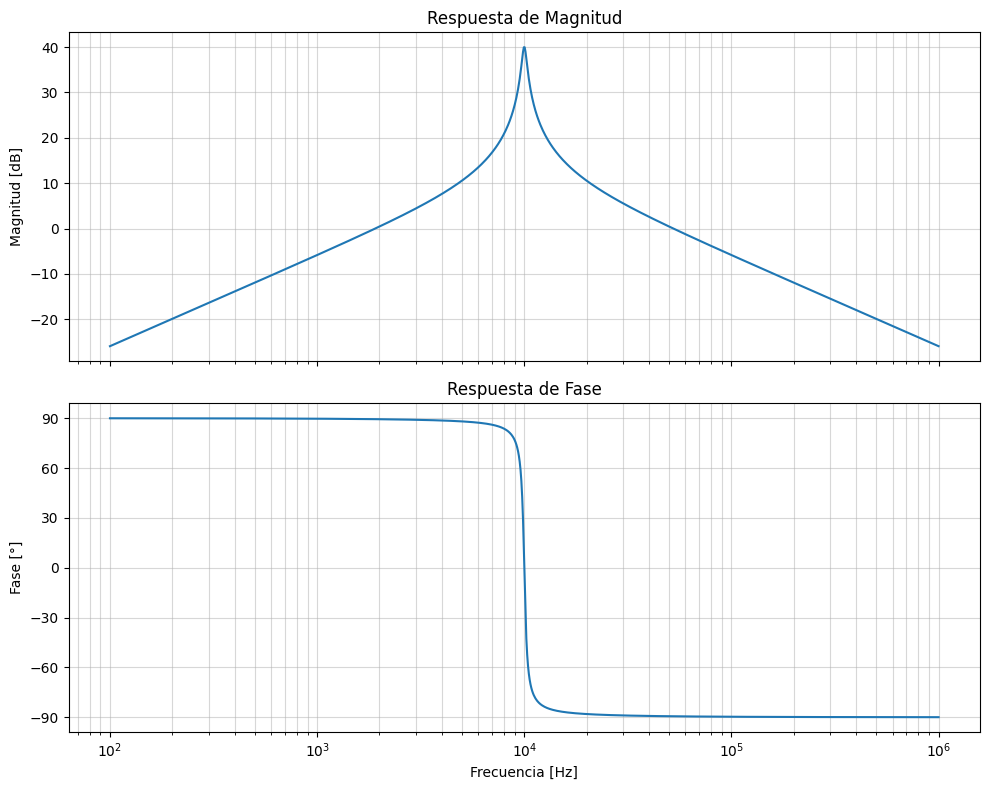

(1, <Axes: xlabel='$\\sigma$', ylabel='j$\\omega$'>)

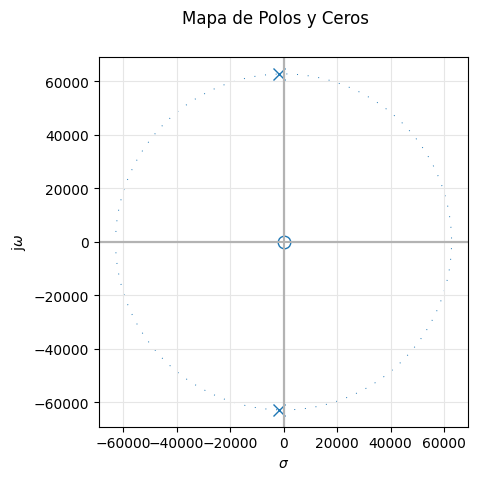

In [3]:
fo = 10000

normaW = 2 * np.pi * fo
normaZ = 1590

#R = 33000
#C = 10 * 1e-9
#C2 = 10 * 1e-9
#R1 = 15000
#R3 = 15000
#R4 = 150000
#R5 = 1500

R = RN*normaZ
C = CN/(normaZ*normaW)
C2 = C2N/(normaZ*normaW)
R1 = R1N*normaZ
R3 = R3N*normaZ
R4 = R4N*normaZ
R5 = R5N*normaZ
L = (C2*R1*R3*R5)/R4

num = np.array([0, (R4+R5)/(C*R5*R), 0])
den = np.array([1, 1/(R*C), 1/(L*C)])

T = TransferFunction(num, den)


f = np.logspace(2, 6, 1000)

w = 2*np.pi*f

w, mag, phase = sig.bode(T,w)

fig, (ax_mag, ax_phase) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)


# Gráfico de Magnitud
ax_mag.semilogx(f, mag)
ax_mag.set_title('Respuesta de Magnitud')
ax_mag.set_ylabel('Magnitud [dB]')
ax_mag.grid(True, which="both", ls="-", alpha=0.5)


# Gráfico de Fase
ticks = np.arange(-90, 91, 30)
ax_phase.set_yticks(ticks)

ax_phase.semilogx(f, phase)
ax_phase.set_title('Respuesta de Fase')
ax_phase.set_ylabel('Fase [°]')
ax_phase.set_xlabel('Frecuencia [Hz]')
ax_phase.grid(True, which="both", ls="-", alpha=0.5)

plt.tight_layout()
plt.show()

pzmap(T)

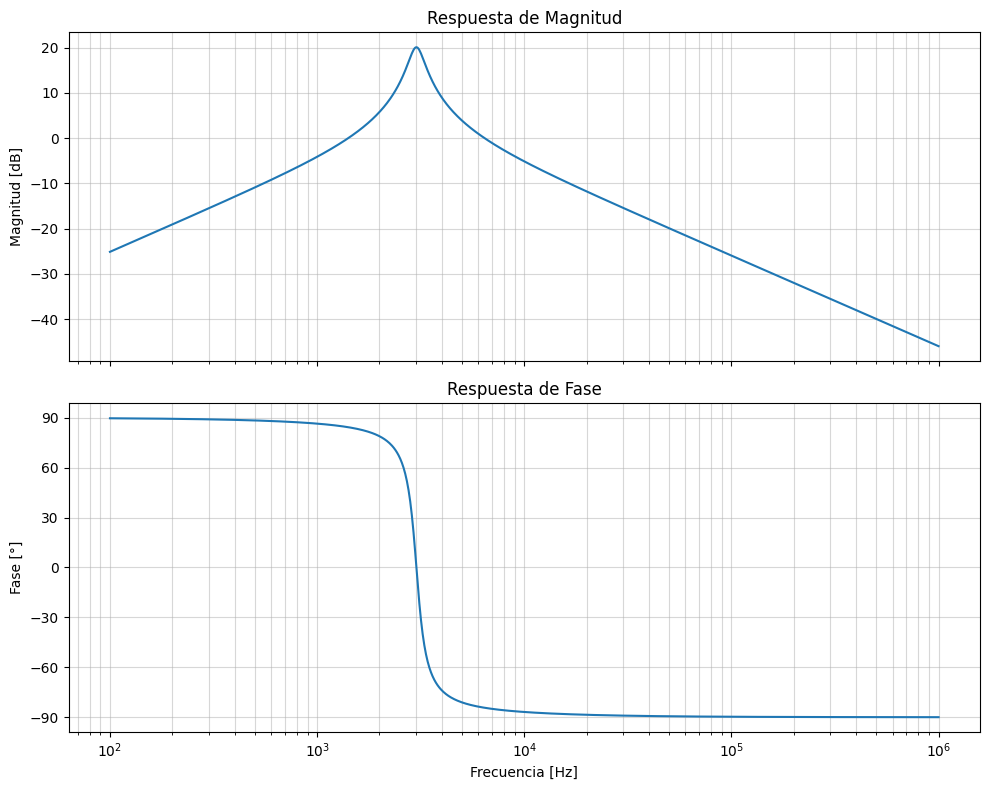

(1, <Axes: xlabel='$\\sigma$', ylabel='j$\\omega$'>)

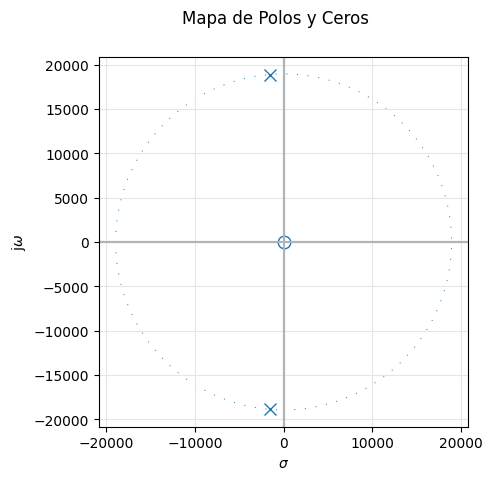

In [25]:
fo = 10000

normaW = 2 * np.pi * fo
normaZ = 1590

#R4 = 16.29 * 1e+6
#R5 = 162.89 * 1e+3
R4 = 100000
R5 = 11000

L = (C2*R1*R3*R5)/R4

num = np.array([0, (R4+R5)/(C*R5*R), 0])
den = np.array([1, 1/(R*C), 1/(L*C)])

T = TransferFunction(num, den)


f = np.logspace(2, 6, 1000)

w = 2*np.pi*f

w, mag, phase = sig.bode(T,w)

fig, (ax_mag, ax_phase) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)


# Gráfico de Magnitud
ax_mag.semilogx(f, mag)
ax_mag.set_title('Respuesta de Magnitud')
ax_mag.set_ylabel('Magnitud [dB]')
ax_mag.grid(True, which="both", ls="-", alpha=0.5)


# Gráfico de Fase
ticks = np.arange(-90, 91, 30)
ax_phase.set_yticks(ticks)

ax_phase.semilogx(f, phase)
ax_phase.set_title('Respuesta de Fase')
ax_phase.set_ylabel('Fase [°]')
ax_phase.set_xlabel('Frecuencia [Hz]')
ax_phase.grid(True, which="both", ls="-", alpha=0.5)

plt.tight_layout()
plt.show()

pzmap(T)

### Bonus 2

<center><img src="./src/img1_TS1.png"></center>


Si bien los circuitos de ambas figuras tienen la misma transferencia, no podemos emular el inductor con el GIC con el que estamos trabajando. Este está diseñado para conectarse en **derivación**, **no en cascada**.
- En la fig.1 el inductor está en derivación, por tanto, lo podemos conectar y su impedancia de entrada será la de un inductor.
- En la fig.2 no podemos reemplazar al componente por la red y que esta lo emule. Necesitamos que el inductor esté "aterrizado" como en la fig 1.


AAAAA